In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("aqi_data_final.csv")

In [3]:
df.head()

,rank,city,country,aqi_value,timestamp,aqi_category
0,1,Kolkata,India,191,2026-03-12 14:45:25,Unhealthy
1,2,Bishkek,Kyrgyzstan,168,2026-03-12 14:45:25,Unhealthy
2,3,Kathmandu,Nepal,166,2026-03-12 14:45:25,Unhealthy
3,4,Beijing,China,164,2026-03-12 14:45:25,Unhealthy
4,5,Kinshasa,Democratic Republic of the Congo,153,2026-03-12 14:45:25,Unhealthy


In [4]:
# Quick look at the data types and nulls
print(df.info())
# Statistical summary of AQI values
print(df['aqi_value'].describe())

<class 'pandas.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   rank          122 non-null    int64
 1   city          122 non-null    str  
 2   country       122 non-null    str  
 3   aqi_value     122 non-null    int64
 4   timestamp     122 non-null    str  
 5   aqi_category  122 non-null    str  
dtypes: int64(2), str(4)
memory usage: 5.8 KB
None
count    122.000000
mean      65.500000
std       39.513205
min        0.000000
25%       36.000000
50%       62.500000
75%       84.000000
max      191.000000
Name: aqi_value, dtype: float64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12904\50018330.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='aqi_category', palette='viridis',


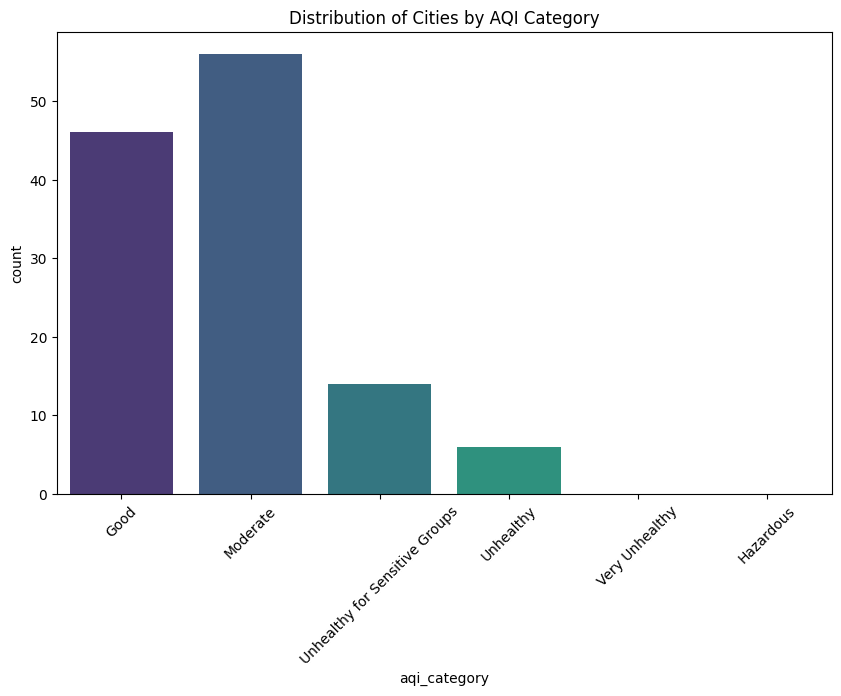

In [ ]:
#AQI Category Distribution (The "Global Health" Check)
#This answers: How is air quality distributed across categories?
# Create a bar chart of categories
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='aqi_category', palette='viridis', 
              order=['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous'])
plt.title('Distribution of Cities by AQI Category')
plt.xticks(rotation=45)
plt.show()

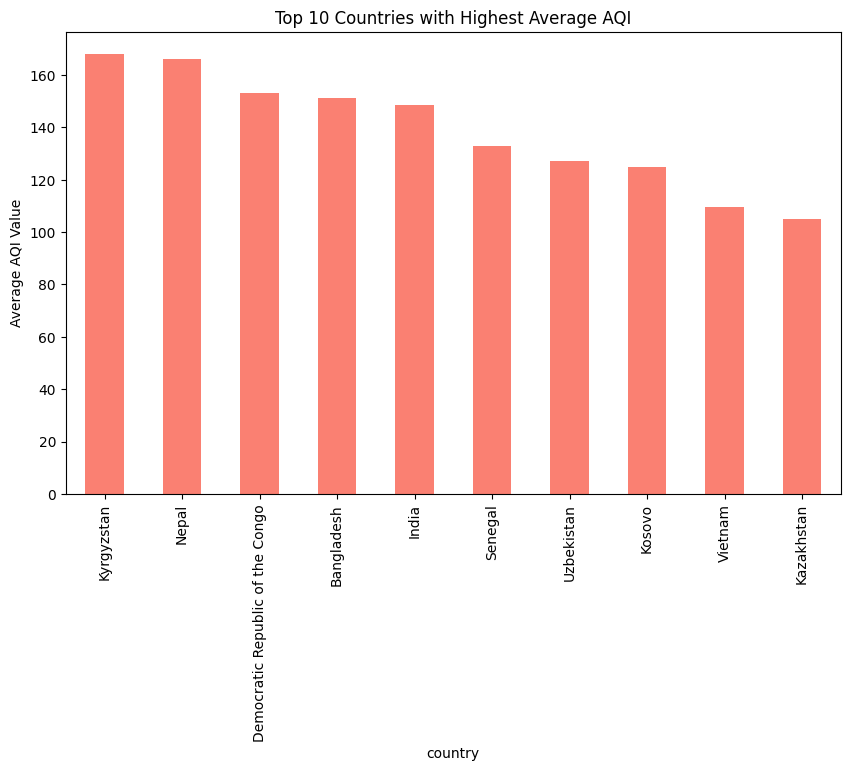

In [6]:
#Top 10 Most Polluted Countries (The "Regional" Pattern)
#This answers: Which countries show the highest average AQI values?
# Grouping by country and calculating the mean AQI
country_comparison = df.groupby('country')['aqi_value'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
country_comparison.plot(kind='bar', color='salmon')
plt.title('Top 10 Countries with Highest Average AQI')
plt.ylabel('Average AQI Value')
plt.show()

In [7]:
#Identifying "Extreme" Hotspots
# This answers: How concentrated are unhealthy levels?
# Filtering for cities above 150 (Unhealthy)
extreme_pollution = df[df['aqi_value'] > 150]
hotspot_counts = extreme_pollution['country'].value_counts()

print("Countries with the most 'Unhealthy' cities right now:")
print(hotspot_counts)

Countries with the most 'Unhealthy' cities right now:
country
India                               1
Kyrgyzstan                          1
Nepal                               1
China                               1
Democratic Republic of the Congo    1
Bangladesh                          1
Name: count, dtype: int64


In [8]:
# Highest average AQI by country
# We filter for countries with more than 1 city for statistical consistency
country_avg = df.groupby('country')['aqi_value'].agg(['mean', 'count']).sort_values('mean', ascending=False)
top_polluted_countries = country_avg[country_avg['count'] > 1].head(10)

print("\nTop 10 Most Polluted Countries (March 2026 Snapshot):")
print(top_polluted_countries)


Top 10 Most Polluted Countries (March 2026 Snapshot):
                   mean  count
country                       
India        148.333333      3
Vietnam      109.500000      2
Israel       100.500000      2
China         95.750000      8
Poland        92.000000      3
Pakistan      89.500000      2
Thailand      82.500000      2
South Korea   81.666667      3
Italy         76.000000      2
Taiwan        61.500000      2


In [9]:
# Identifying cities with "Hazardous" or "Very Unhealthy" levels
high_risk_cities = df[df['aqi_value'] > 200].sort_values('aqi_value', ascending=False)
print("\nCities currently in the 'Very Unhealthy' or 'Hazardous' zones:")
print(high_risk_cities[['city', 'country', 'aqi_value']])


Cities currently in the 'Very Unhealthy' or 'Hazardous' zones:
Empty DataFrame
Columns: [city, country, aqi_value]
Index: []
